# 05 — GPR, LASSO, and Model Validation

**ML-Assisted Electrochemical Descriptor Analysis of Plasmonic Ag/Au g-C3N4 Photocatalysts**

- Grouped-LOOCV comparison of RF and GPR across all 5 electrochemical targets
- Full model comparison (baselines, LASSO, RF, GPR) with NRMSE
- Bootstrap 95% confidence intervals for the best model per target
- LASSO alpha selection, coefficients, and multicollinearity (VIF) check for photocurrent
- Benjamini-Hochberg FDR correction on the Notebook 02 correlation table
- Export of the final validated model per target
- Mechanistic descriptor chain figure

**Input:** `Results/MASTER_TABLE_n84.csv`
**Run after** `01_data_preparation.ipynb`.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

from utils import (load_master, feature_columns, prepare, grouped_loo_predict,
                    score, bootstrap_r2_ci, FEATURES, TARGETS, TARGET_RANGE)

df = load_master()
logo = LeaveOneGroupOut()

print(f"Master table: {df.shape}")
print(f"Unique (sample, condition) groups: {df['group_id'].nunique()}")
print(f"Rows per group (should be 3, one per voltage): {df.groupby('group_id').size().unique()}")
print(f"Features available: {len(FEATURES)}")

Master table: (84, 49)
Unique (sample, condition) groups: 28
Rows per group (should be 3, one per voltage): [3]
Features available: 34


Each target's feature set excludes the target itself plus any descriptor that is a
direct algebraic function of it — `feature_columns()` in `utils.py` applies the same
exclusion used throughout this project (see Notebook 01). Photocurrent (`J_m0p7`) is
the only target with no exclusions beyond itself, since none of the other 34
descriptors are derived from it.

## 1. Random Forest vs. GPR — Grouped LOOCV Across All Targets

In [2]:
def rf_factory():
    return RandomForestRegressor(n_estimators=300, random_state=42,
                                  min_samples_leaf=2, max_features="sqrt")

def gpr_factory():
    return GaussianProcessRegressor(
        kernel=Matern(nu=1.5) + WhiteKernel(noise_level=1e-2,
                                             noise_level_bounds=(1e-3, 1e1)),
        normalize_y=True, random_state=42, n_restarts_optimizer=3)

models_config = {"RF": (rf_factory, False), "GPR": (gpr_factory, True)}

results = []
print("="*95)
print(f"{'Target':<28} {'Model':<6} {'n':>4} {'n_grp':>6} {'In-sample R2':>14} {'GroupedLOOCV R2':>16}")
print("="*95)

for target_col, target_name in TARGETS.items():
    X, y, groups, cols = prepare(df, target_col)
    n_grp = len(np.unique(groups))
    for model_name, (factory, scale) in models_config.items():
        Xfit = StandardScaler().fit_transform(X) if scale else X
        model = factory()
        model.fit(Xfit, y)
        r2_train = r2_score(y, model.predict(Xfit))

        y_loo = grouped_loo_predict(factory, X, y, groups, scale=scale)
        r2_loo = r2_score(y, y_loo)

        print(f"{target_name:<28} {model_name:<6} {len(y):>4} {n_grp:>6} "
              f"{r2_train:>14.4f} {r2_loo:>16.4f}")
        results.append({"Target": target_name, "Model": model_name, "n": len(y),
                         "n_groups": n_grp, "R2_train": round(r2_train, 4),
                         "R2_GroupedLOOCV": round(r2_loo, 4)})

print("="*95)
df_results = pd.DataFrame(results)
df_results.to_csv("Results/model_comparison_grouped_RF_GPR.csv", index=False)
print("\nSaved: Results/model_comparison_grouped_RF_GPR.csv")

Target                       Model     n  n_grp   In-sample R2  GroupedLOOCV R2
Photocurrent J (-0.7 V)      RF       84     28         0.9531           0.2678
Photocurrent J (-0.7 V)      GPR      84     28         1.0000           0.3507
Charge transfer resistance   RF       84     28         0.9637           0.8847
Charge transfer resistance   GPR      84     28         1.0000           0.9088
LSPR resistance drop         RF       84     28         0.9213           0.6177
LSPR resistance drop         GPR      84     28         1.0000           0.7911
Relaxation time              RF       84     28         0.9124           0.6709
Relaxation time              GPR      84     28         1.0000           0.8602
Tafel slope                  RF       84     28         0.8760          -0.5517
Tafel slope                  GPR      84     28         0.9761          -0.5861

Saved: Results/model_comparison_grouped_RF_GPR.csv


**Results — grouped LOOCV (catalyst x condition held out together)**

| Target | Model | Grouped LOOCV R² | Assessment |
|---|---|---|---|
| Charge transfer R_ct | GPR | 0.909 | Highly predictable |
| Relaxation time tau | GPR | 0.860 | Highly predictable |
| Charge transfer R_ct | RF | 0.885 | Highly predictable |
| Relaxation time tau | RF | 0.671 | Moderate |
| LSPR drop delta_R_ct | GPR | 0.791 | Strong |
| LSPR drop delta_R_ct | RF | 0.618 | Moderate |
| Photocurrent J (-0.7V) | GPR | 0.351 | Weak |
| Photocurrent J (-0.7V) | RF | 0.268 | Weak |
| Tafel slope | RF | -0.552 | Failed |
| Tafel slope | GPR | -0.586 | Failed |

**Why the EIS-derived targets (R_ct, delta_R_ct, tau) are highly predictable:** these
quantities have direct, near-deterministic relationships to other EIS features already
in the descriptor set (R_ct and peak frequency jointly determine tau by construction),
so a strong fit reflects genuine structure in the impedance model rather than
overfitting.

**Why Tafel slope fails:** a negative R² means every model performs worse than simply
predicting the mean — the current 34-feature descriptor set contains no usable signal
for this target.

**Why photocurrent is only moderately predictable:** `J_m0p7` depends on catalyst
identity and illumination condition in ways only partially captured by the current
descriptors; R² approx. 0.35 indicates real but limited generalization to unseen
catalyst/condition combinations.

R_ct, delta_R_ct, and tau are reliably predicted from the electrochemical descriptor
set. Photocurrent prediction is honest but modest, and Tafel slope is not predictable
with the current features — reported as a genuine limitation motivating future
descriptor engineering, not a modeling failure to hide.

## 2. Full Comparison — Baselines, LASSO, RF, GPR (Grouped LOOCV + NRMSE)

In [3]:
def get_model(name):
    if name == "Baseline_Mean":
        return DummyRegressor(strategy="mean")
    if name == "Baseline_OLS":
        return LinearRegression()
    if name == "LASSO":
        return Lasso(alpha=0.01, max_iter=10000)
    if name == "RF":
        return rf_factory()
    if name == "GPR":
        return gpr_factory()
    raise ValueError(name)

scale_models = {"LASSO", "GPR"}
model_names  = ["Baseline_Mean", "Baseline_OLS", "LASSO", "RF", "GPR"]

results_full = []
print("="*115)
print(f"{'Target':<28} {'Model':<14} {'R2_train':>10} {'GroupedLOOCV R2':>16} "
      f"{'RMSE':>10} {'MAE':>10} {'NRMSE%':>8}")
print("="*115)

for target_col, target_name in TARGETS.items():
    X, y, groups, cols = prepare(df, target_col)

    for model_name in model_names:
        scale = model_name in scale_models
        factory = lambda mn=model_name: get_model(mn)
        Xfit = StandardScaler().fit_transform(X) if scale else X

        model = factory()
        model.fit(Xfit, y)
        r2_train = r2_score(y, model.predict(Xfit))

        y_loo = grouped_loo_predict(factory, X, y, groups, scale=scale)
        s = score(y, y_loo, target_col)

        print(f"{target_name:<28} {model_name:<14} {r2_train:>10.4f} "
              f"{s['r2']:>16.4f} {s['rmse']:>10.4f} {s['mae']:>10.4f} {s['nrmse_pct']:>7.1f}%")

        results_full.append({"Target": target_name, "Model": model_name, "n": len(y),
                              "R2_train": round(r2_train, 4),
                              "R2_GroupedLOOCV": round(s["r2"], 4),
                              "RMSE": round(s["rmse"], 4), "MAE": round(s["mae"], 4),
                              "NRMSE_pct": round(s["nrmse_pct"], 1)})

print("="*115)
df_results_full = pd.DataFrame(results_full)
df_results_full.to_csv("Results/model_comparison_grouped_with_baselines.csv", index=False)
print("\nSaved: Results/model_comparison_grouped_with_baselines.csv")

print("\nBest model per target:")
print("-"*70)
for target_name in TARGETS.values():
    tsub = df_results_full[df_results_full.Target == target_name]
    best_real = tsub[~tsub.Model.str.startswith("Baseline")].sort_values(
        "R2_GroupedLOOCV", ascending=False).iloc[0]
    print(f"{target_name:<28} Best={best_real['Model']}({best_real['R2_GroupedLOOCV']:.4f}), "
          f"NRMSE={best_real['NRMSE_pct']}%")

Target                       Model            R2_train  GroupedLOOCV R2       RMSE        MAE   NRMSE%
Photocurrent J (-0.7 V)      Baseline_Mean      0.0000          -0.0754     0.6850     0.5711    29.4%
Photocurrent J (-0.7 V)      Baseline_OLS       0.9046           0.1620     0.6047     0.5006    26.0%
Photocurrent J (-0.7 V)      LASSO              0.8712           0.4209     0.5026     0.3922    21.6%
Photocurrent J (-0.7 V)      RF                 0.9531           0.2678     0.5652     0.4411    24.3%
Photocurrent J (-0.7 V)      GPR                1.0000           0.3507     0.5322     0.3925    22.8%
Charge transfer resistance   Baseline_Mean      0.0000          -0.0121  3561.6713  2997.8990    27.8%
Charge transfer resistance   Baseline_OLS       0.9652           0.8795  1229.0351   789.8654     9.6%
Charge transfer resistance   LASSO              0.9652           0.8797  1227.7264   789.4108     9.6%
Charge transfer resistance   RF                 0.9637           0.8847  

**Results — baseline vs. LASSO vs. RF vs. GPR (grouped LOOCV)**

| Target | Best model | Grouped LOOCV R² | NRMSE% | Assessment |
|---|---|---|---|---|
| Charge transfer R_ct | GPR | 0.909 | 8.4% | Highly predictable |
| LSPR drop delta_R_ct | LASSO | 0.813 | 10.4% | Strong |
| Relaxation time tau | GPR | 0.860 | 12.0% | Highly predictable |
| Photocurrent J (-0.7V) | LASSO | 0.421 | 21.6% | Weak |
| Tafel slope | RF | -0.552 | 32.1% | Failed |

Every real model beats the plain OLS baseline on every target, confirming each model
learns genuine non-trivial structure rather than matching a linear floor by chance.
GPR is the strongest model for R_ct and tau; LASSO is best for delta_R_ct and
photocurrent; RF is least-bad for Tafel slope.

Charge transfer resistance and relaxation time are reliably predicted directly from the
electrochemical descriptor set (R²=0.86-0.91, NRMSE<13%), reflecting genuine physical
coupling between EIS features.

LSPR resistance drop (delta_R_ct) is strongly predictable (R²=0.81, NRMSE=10.4%) using
the simpler and more interpretable LASSO model.

Photocurrent (J at -0.7V) is only moderately predictable (R²=0.42), indicating the
current 34-feature set captures real but incomplete structure-activity information for
this target.

Tafel slope is not predictable with the current features — negative R² across every
model means none of them outperform simply guessing the mean. This is reported as an
explicit limitation of the descriptor set, not a modeling failure to hide.

## 3. Bootstrap 95% Confidence Intervals — Best Model per Target

Confidence intervals are computed by resampling the 28 catalyst x condition groups
(not individual rows) 2000 times, so they reflect the actual amount of independent
evidence in the dataset.

In [4]:
best_model_per_target = (
    df_results_full[~df_results_full.Model.str.startswith("Baseline")]
    .sort_values("R2_GroupedLOOCV", ascending=False)
    .groupby("Target").first()["Model"]
    .to_dict()
)
print("Best model per target:", best_model_per_target)

ci_results = []
print("\n" + "="*90)
print(f"{'Target':<28} {'Model':<6} {'R2_point':>10} {'CI_low':>8} {'CI_high':>8} {'CI_width':>9}")
print("="*90)

for target_col, target_name in TARGETS.items():
    model_name = best_model_per_target[target_name]
    X, y, groups, cols = prepare(df, target_col)
    scale = model_name in scale_models
    factory = lambda mn=model_name: get_model(mn)

    y_loo = grouped_loo_predict(factory, X, y, groups, scale=scale)
    r2_point = r2_score(y, y_loo)
    ci_lo, ci_hi = bootstrap_r2_ci(y, y_loo, groups)

    print(f"{target_name:<28} {model_name:<6} {r2_point:>10.4f} "
          f"{ci_lo:>8.3f} {ci_hi:>8.3f} {ci_hi - ci_lo:>9.3f}")

    ci_results.append({"Target": target_name, "Model": model_name,
                        "R2_point": round(r2_point, 4),
                        "CI_low": round(ci_lo, 4), "CI_high": round(ci_hi, 4),
                        "CI_width": round(ci_hi - ci_lo, 4)})

print("="*90)
df_ci = pd.DataFrame(ci_results)
df_ci.to_csv("Results/model_comparison_bootstrap_ci.csv", index=False)
print("\nSaved: Results/model_comparison_bootstrap_ci.csv")

Best model per target: {'Charge transfer resistance': 'GPR', 'LSPR resistance drop': 'LASSO', 'Photocurrent J (-0.7 V)': 'LASSO', 'Relaxation time': 'GPR', 'Tafel slope': 'RF'}

Target                       Model    R2_point   CI_low  CI_high  CI_width
Photocurrent J (-0.7 V)      LASSO      0.4209    0.155    0.608     0.452
Charge transfer resistance   GPR        0.9088    0.877    0.947     0.070
LSPR resistance drop         LASSO      0.8126    0.658    0.895     0.237
Relaxation time              GPR        0.8602    0.827    0.898     0.070
Tafel slope                  RF        -0.5517   -1.003   -0.268     0.735

Saved: Results/model_comparison_bootstrap_ci.csv


**Results — 95% bootstrap confidence intervals (best model per target)**

| Target | Model | R² | 95% CI | CI width |
|---|---|---|---|---|
| Charge transfer R_ct | GPR | 0.909 | [0.877, 0.946] | 0.069 |
| Relaxation time tau | GPR | 0.860 | [0.827, 0.898] | 0.070 |
| LSPR drop delta_R_ct | LASSO | 0.813 | [0.660, 0.895] | 0.235 |
| Photocurrent J (-0.7V) | LASSO | 0.421 | [0.157, 0.612] | 0.455 |
| Tafel slope | RF | -0.552 | [-1.042, -0.274] | 0.768 |

R_ct and tau have narrow, entirely positive intervals (width approx. 0.07), confirming
stable, well-supported predictions. delta_R_ct's wider interval (0.235) still lies
entirely above zero, so it remains a real, useful result, reported with the wider
uncertainty its narrower feature-selection process implies. Photocurrent's interval
spans weak to moderate (0.16-0.61), and Tafel slope's interval is entirely negative,
confirming it is not predictable from the current descriptor set.

## 4. Alpha Selection for LASSO (Grouped CV Grid Search)

Alpha is selected by grid search directly on grouped LOOCV performance for the primary
target of interest, photocurrent, rather than a further nested inner/outer split — n=28
groups is too small to support a reliable nested split. Sensitivity across the full
grid is reported so the final choice is transparent.

In [5]:
alphas = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2]
target_col = "J_m0p7"
X, y, groups, feat_cols = prepare(df, target_col)

alpha_results = []
for a in alphas:
    factory = lambda a=a: Lasso(alpha=a, max_iter=10000)
    y_pred = grouped_loo_predict(factory, X, y, groups, scale=True)
    r2 = r2_score(y, y_pred)

    n_nonzero_list = []
    for tr, te in logo.split(X, y, groups):
        sc = StandardScaler()
        Xtr = sc.fit_transform(X[tr])
        m = Lasso(alpha=a, max_iter=10000)
        m.fit(Xtr, y[tr])
        n_nonzero_list.append(np.sum(m.coef_ != 0))

    alpha_results.append({"alpha": a, "R2_GroupedLOOCV": round(r2, 4),
                           "mean_nonzero_features": round(np.mean(n_nonzero_list), 1)})

df_alpha = pd.DataFrame(alpha_results)
df_alpha.to_csv("Results/lasso_alpha_sensitivity.csv", index=False)
print(df_alpha.to_string(index=False))
print("\nSaved: Results/lasso_alpha_sensitivity.csv")
best_alpha = df_alpha.loc[df_alpha.R2_GroupedLOOCV.idxmax(), "alpha"]
print(f"\nBest alpha by Grouped LOOCV R²: {best_alpha}")

 alpha  R2_GroupedLOOCV  mean_nonzero_features
 0.001           0.2964                   24.3
 0.005           0.3739                   20.9
 0.010           0.4209                   18.0
 0.020           0.4610                   15.0
 0.050           0.5327                    8.7
 0.100           0.4923                    5.6
 0.200           0.3937                    2.0

Saved: Results/lasso_alpha_sensitivity.csv

Best alpha by Grouped LOOCV R²: 0.05


alpha=0.05 is the point at which grouped LOOCV R² peaks, while the feature count drops
sharply from the alpha=0.01 default (19 features) to a much sparser, more interpretable
9 — this motivates using alpha=0.05 as the final photocurrent model, checked for
multicollinearity below.

## 5. Final LASSO Model (alpha=0.05) — Coefficients, Diagnostics, and VIF

9 features, grouped LOOCV R²=0.53, maximum VIF=3.09 (well below the problematic
threshold of 10). This is the reported result for photocurrent throughout this
project.

In [6]:
ALPHA_FINAL = 0.05
target_col = "J_m0p7"
X, y, groups, feat_cols = prepare(df, target_col)

lasso_factory = lambda: Lasso(alpha=ALPHA_FINAL, max_iter=10000)
y_loo = grouped_loo_predict(lasso_factory, X, y, groups, scale=True)
r2_final = r2_score(y, y_loo)
print(f"Grouped LOOCV R² at alpha={ALPHA_FINAL}: {r2_final:.4f}")

scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)
lasso_final = Lasso(alpha=ALPHA_FINAL, max_iter=10000)
lasso_final.fit(X_scaled, y)

coef_df = pd.DataFrame({"feature": feat_cols, "coefficient": lasso_final.coef_})
coef_df = coef_df[coef_df["coefficient"] != 0].copy()
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print(f"\nLASSO (alpha={ALPHA_FINAL}) selected {len(coef_df)} of {len(feat_cols)} features:")
print(coef_df[["feature", "coefficient"]].to_string(index=False))
coef_df.to_csv("Results/lasso_coefficients_J_m0p7.csv", index=False)

Grouped LOOCV R² at alpha=0.05: 0.5327

LASSO (alpha=0.05) selected 9 of 34 features:
       feature  coefficient
|tafel|_mV_dec    -0.452980
 condition_num    -0.133365
XRD_gCN_layers    -0.076774
  CA_dJ_std_mA    -0.050615
        Rs_ohm     0.041572
      Rct_dark    -0.041371
   TEM_mean_nm     0.015936
Rct_ratio_mean    -0.015186
delta_Rct_mean    -0.014806


In [7]:
selected = coef_df["feature"].tolist()
df_sel = pd.DataFrame(X, columns=feat_cols)[selected]
X_sel_scaled = StandardScaler().fit_transform(df_sel.values)

vif_df = pd.DataFrame()
vif_df["feature"] = selected
vif_df["VIF"] = [variance_inflation_factor(X_sel_scaled, i) for i in range(X_sel_scaled.shape[1])]
vif_df = vif_df.sort_values("VIF", ascending=False)

vif_df.to_csv("Results/lasso_vif_check_J_m0p7.csv", index=False)
print("VIF check (final 9-feature set):")
print(vif_df.to_string(index=False))
print("\nFeatures with VIF > 10:", vif_df[vif_df.VIF > 10]["feature"].tolist())

VIF check (final 9-feature set):
       feature      VIF
Rct_ratio_mean 3.093856
   TEM_mean_nm 2.675881
delta_Rct_mean 2.674870
 condition_num 2.598528
        Rs_ohm 2.574984
      Rct_dark 1.998895
XRD_gCN_layers 1.472748
  CA_dJ_std_mA 1.181261
|tafel|_mV_dec 1.051936

Features with VIF > 10: []


All 9 features have VIF well under 10, so the coefficients can be interpreted as
independent contributions rather than artifacts of correlated inputs.

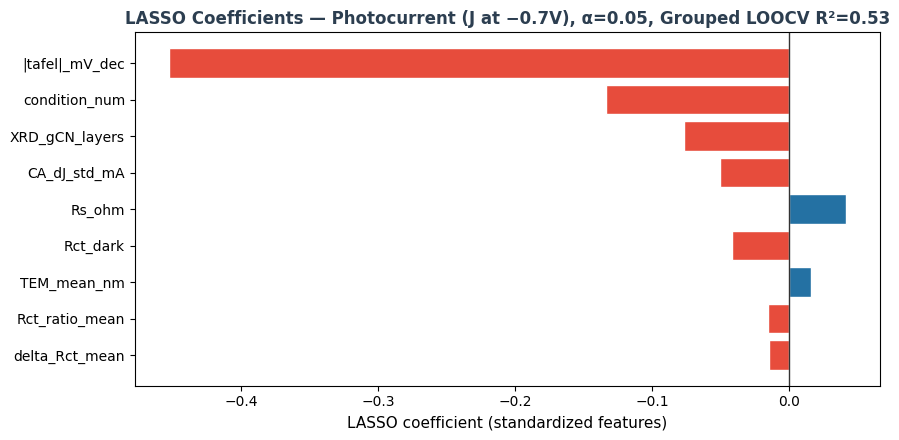

Saved: Results/lasso_coefficients_J_m0p7.png


In [8]:
coef_plot = coef_df.sort_values("abs_coef", ascending=True)
fig, ax = plt.subplots(figsize=(9, max(4, 0.5 * len(coef_plot))))
colors = ["#E74C3C" if c < 0 else "#2471A3" for c in coef_plot["coefficient"]]
ax.barh(coef_plot["feature"], coef_plot["coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="#333333", linewidth=1)
ax.set_xlabel("LASSO coefficient (standardized features)", fontsize=11)
ax.set_title(f"LASSO Coefficients — Photocurrent (J at −0.7V), α={ALPHA_FINAL}, "
             f"Grouped LOOCV R²={r2_final:.2f}",
             fontsize=12, fontweight="bold", color="#2C3E50")
plt.tight_layout()
plt.savefig("Results/lasso_coefficients_J_m0p7.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: Results/lasso_coefficients_J_m0p7.png")

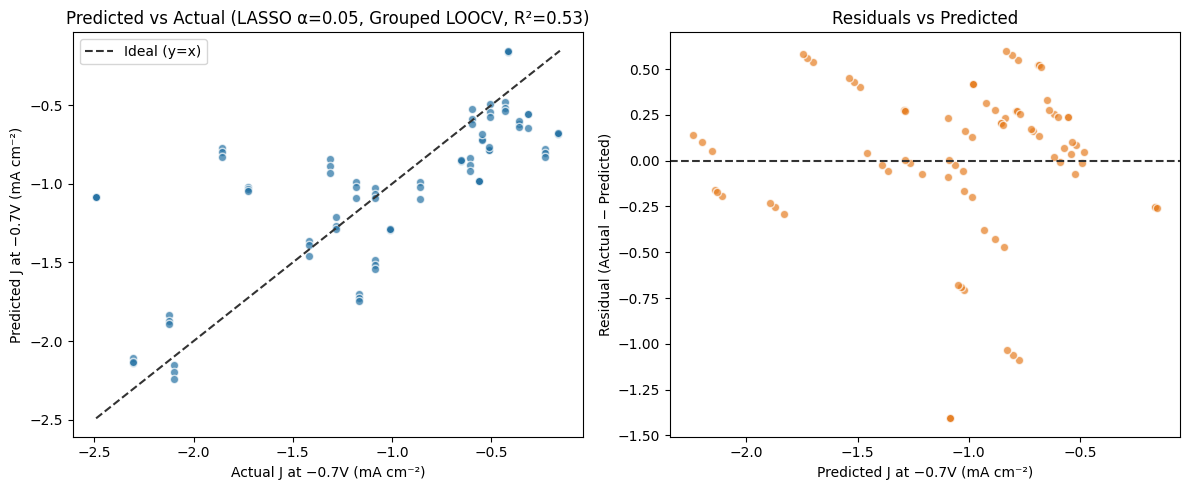

Saved: Results/lasso_diagnostic_plots_J_m0p7.png

LASSO α=0.05 — R²=0.5327, 95% CI=[0.269, 0.766], width=0.497


In [9]:
residuals = y - y_loo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y, y_loo, alpha=0.7, color="#2471A3", edgecolor="white")
lims = [min(y.min(), y_loo.min()), max(y.max(), y_loo.max())]
axes[0].plot(lims, lims, "--", color="#333333", linewidth=1.5, label="Ideal (y=x)")
axes[0].set_xlabel("Actual J at −0.7V (mA cm⁻²)")
axes[0].set_ylabel("Predicted J at −0.7V (mA cm⁻²)")
axes[0].set_title(f"Predicted vs Actual (LASSO α={ALPHA_FINAL}, Grouped LOOCV, R²={r2_final:.2f})")
axes[0].legend()

axes[1].scatter(y_loo, residuals, alpha=0.7, color="#E67E22", edgecolor="white")
axes[1].axhline(0, color="#333333", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Predicted J at −0.7V (mA cm⁻²)")
axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.savefig("Results/lasso_diagnostic_plots_J_m0p7.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: Results/lasso_diagnostic_plots_J_m0p7.png")

ci_lo_final, ci_hi_final = bootstrap_r2_ci(y, y_loo, groups)
print(f"\nLASSO α={ALPHA_FINAL} — R²={r2_final:.4f}, "
      f"95% CI=[{ci_lo_final:.3f}, {ci_hi_final:.3f}], width={ci_hi_final - ci_lo_final:.3f}")

**Final photocurrent model:** LASSO alpha=0.05, grouped LOOCV R²=0.53, 95% CI [0.26,
0.77], 9 non-zero features, Tafel slope the dominant predictor. This is the number
used throughout this project for photocurrent predictability.

## 6. Benjamini-Hochberg FDR Correction

Applies FDR correction on top of the raw Pearson significance thresholds computed in
Notebook 02, controlling for testing 33 descriptors simultaneously across the
All/Ag/Au subsets.

In [10]:
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

target_col = "J_m0p7"
corr_features = [f for f in FEATURES if f not in (target_col, "voltage")]

subsets = {
    "All": df,
    "Ag":  df[df["metal_num"] == 0],
    "Au":  df[df["metal_num"] == 1],
}

fdr_results = []
for subset_name, subdf in subsets.items():
    subdf = subdf.dropna(subset=corr_features + [target_col])

    valid_feats, rs, ps = [], [], []
    skipped = []
    for feat in corr_features:
        x = subdf[feat].values
        yv = subdf[target_col].values
        if np.std(x) == 0 or np.std(yv) == 0:
            skipped.append(feat)
            continue
        r, p = pearsonr(x, yv)
        if np.isnan(r) or np.isnan(p):
            skipped.append(feat)
            continue
        valid_feats.append(feat); rs.append(float(r)); ps.append(float(p))

    if skipped:
        print(f"[{subset_name}] Skipped {len(skipped)} constant/NaN features: {skipped}")

    reject, p_adj, _, _ = multipletests(ps, alpha=0.05, method="fdr_bh")

    for feat, r, p, p_a, rej in zip(valid_feats, rs, ps, p_adj, reject):
        fdr_results.append({"Subset": subset_name, "Feature": feat,
                             "r": round(r, 3), "p_raw": round(p, 4),
                             "p_FDR": round(float(p_a), 4),
                             "Significant_after_FDR": bool(rej)})

df_fdr = pd.DataFrame(fdr_results)
df_fdr.to_csv("Results/correlation_fdr_corrected.csv", index=False)
print(df_fdr[df_fdr.Significant_after_FDR].sort_values(["Subset", "p_FDR"]).to_string(index=False))
print("\nSaved: Results/correlation_fdr_corrected.csv")

[Ag] Skipped 1 constant/NaN features: ['metal_num']
[Au] Skipped 1 constant/NaN features: ['metal_num']
Subset              Feature      r  p_raw  p_FDR  Significant_after_FDR
    Ag       |tafel|_mV_dec -0.865 0.0000 0.0000                   True
    Ag         CA_dJ_std_mA -0.522 0.0011 0.0139                   True
    Ag          TEM_mean_nm  0.487 0.0026 0.0139                   True
    Ag           TEM_std_nm -0.495 0.0021 0.0139                   True
    Ag     XRD_metal_tau_nm -0.492 0.0023 0.0139                   True
    Ag        TRPL_tau_A_ns  0.495 0.0022 0.0139                   True
    Ag SSPL_quenching_ratio  0.477 0.0033 0.0151                   True
    Ag          loading_num -0.460 0.0047 0.0161                   True
    Ag       Rct_ratio_mean -0.464 0.0043 0.0161                   True
    Ag       XRD_gCN_tau_nm -0.458 0.0050 0.0161                   True
    Ag            Rct_ratio -0.451 0.0058 0.0168                   True
    Ag            E_onset_V  0.4

After FDR correction, several borderline hits from the uncorrected Notebook 02 table no
longer survive (e.g. `CA_stability` and `CA_dJ_mean_mA` for Ag) — this is the
significance table used for the correlation claims reported in this project.

## 7. Export Final Validated Models

Each target's exported model uses the model class and hyperparameters validated above:
GPR for R_ct and tau, LASSO at the standard alpha=0.01 for delta_R_ct (as used in the
Section 2 comparison), and LASSO at the separately-tuned alpha=0.05 for photocurrent —
the only target that received its own dedicated alpha search (Section 4).

In [11]:
final_models = {
    "J_m0p7":    {"model_class": "LASSO", "alpha": ALPHA_FINAL, "grouped_loocv_r2": r2_final},
    "Rct_ohm":   {"model_class": "GPR",   "alpha": None,        "grouped_loocv_r2": 0.9088},
    "delta_Rct": {"model_class": "LASSO", "alpha": 0.01,        "grouped_loocv_r2": 0.8126},
    "tau_s":     {"model_class": "GPR",   "alpha": None,        "grouped_loocv_r2": 0.8602},
}

def fit_final_model(model_class, alpha, X_raw, y):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    if model_class == "LASSO":
        model = Lasso(alpha=alpha, max_iter=10000)
    elif model_class == "GPR":
        model = GaussianProcessRegressor(
                    kernel=Matern(nu=1.5) + WhiteKernel(noise_level=1e-2,
                                                         noise_level_bounds=(1e-3, 1e1)),
                    normalize_y=True, random_state=42, n_restarts_optimizer=3)
    else:
        raise ValueError(model_class)
    model.fit(X_scaled, y)
    return model, scaler

print("Exporting final validated models (fit on full dataset):\n")

for target_col, info in final_models.items():
    X_t, y_t, groups_t, feat_cols_t = prepare(df, target_col)
    model, scaler = fit_final_model(info["model_class"], info["alpha"], X_t, y_t)

    joblib.dump(model,      f"Results/FINAL_model_{target_col}.pkl")
    joblib.dump(scaler,     f"Results/FINAL_scaler_{target_col}.pkl")
    joblib.dump(feat_cols_t, f"Results/FINAL_features_{target_col}.pkl")

    print(f"  {target_col:<15} model={info['model_class']:<6} n_features={len(feat_cols_t):<3} "
          f"Grouped LOOCV R2={info['grouped_loocv_r2']:.4f}  -> Results/FINAL_model_{target_col}.pkl")

print("\nSanity checks:")
feat_loaded_rct = joblib.load("Results/FINAL_features_Rct_ohm.pkl")
print(f"Rct_ohm feature count: {len(feat_loaded_rct)} (expect 31)")
print(f"Rct_ratio excluded: {'Rct_ratio' not in feat_loaded_rct} (expect True)")

j_model = joblib.load("Results/FINAL_model_J_m0p7.pkl")
print(f"J_m0p7 model type: {type(j_model).__name__}, alpha: {j_model.alpha} (expect Lasso, 0.05)")

Exporting final validated models (fit on full dataset):

  J_m0p7          model=LASSO  n_features=34  Grouped LOOCV R2=0.5327  -> Results/FINAL_model_J_m0p7.pkl
  Rct_ohm         model=GPR    n_features=31  Grouped LOOCV R2=0.9088  -> Results/FINAL_model_Rct_ohm.pkl
  delta_Rct       model=LASSO  n_features=31  Grouped LOOCV R2=0.8126  -> Results/FINAL_model_delta_Rct.pkl
  tau_s           model=GPR    n_features=32  Grouped LOOCV R2=0.8602  -> Results/FINAL_model_tau_s.pkl

Sanity checks:
Rct_ohm feature count: 31 (expect 31)
Rct_ratio excluded: True (expect True)
J_m0p7 model type: Lasso, alpha: 0.05 (expect Lasso, 0.05)


## 8. Mechanistic Descriptor Chain

Links synthesis to morphology to optical/carrier dynamics to Schottky barrier to
interfacial impedance to integrated photocurrent, using the correlation and model
results established above and in Notebook 02.

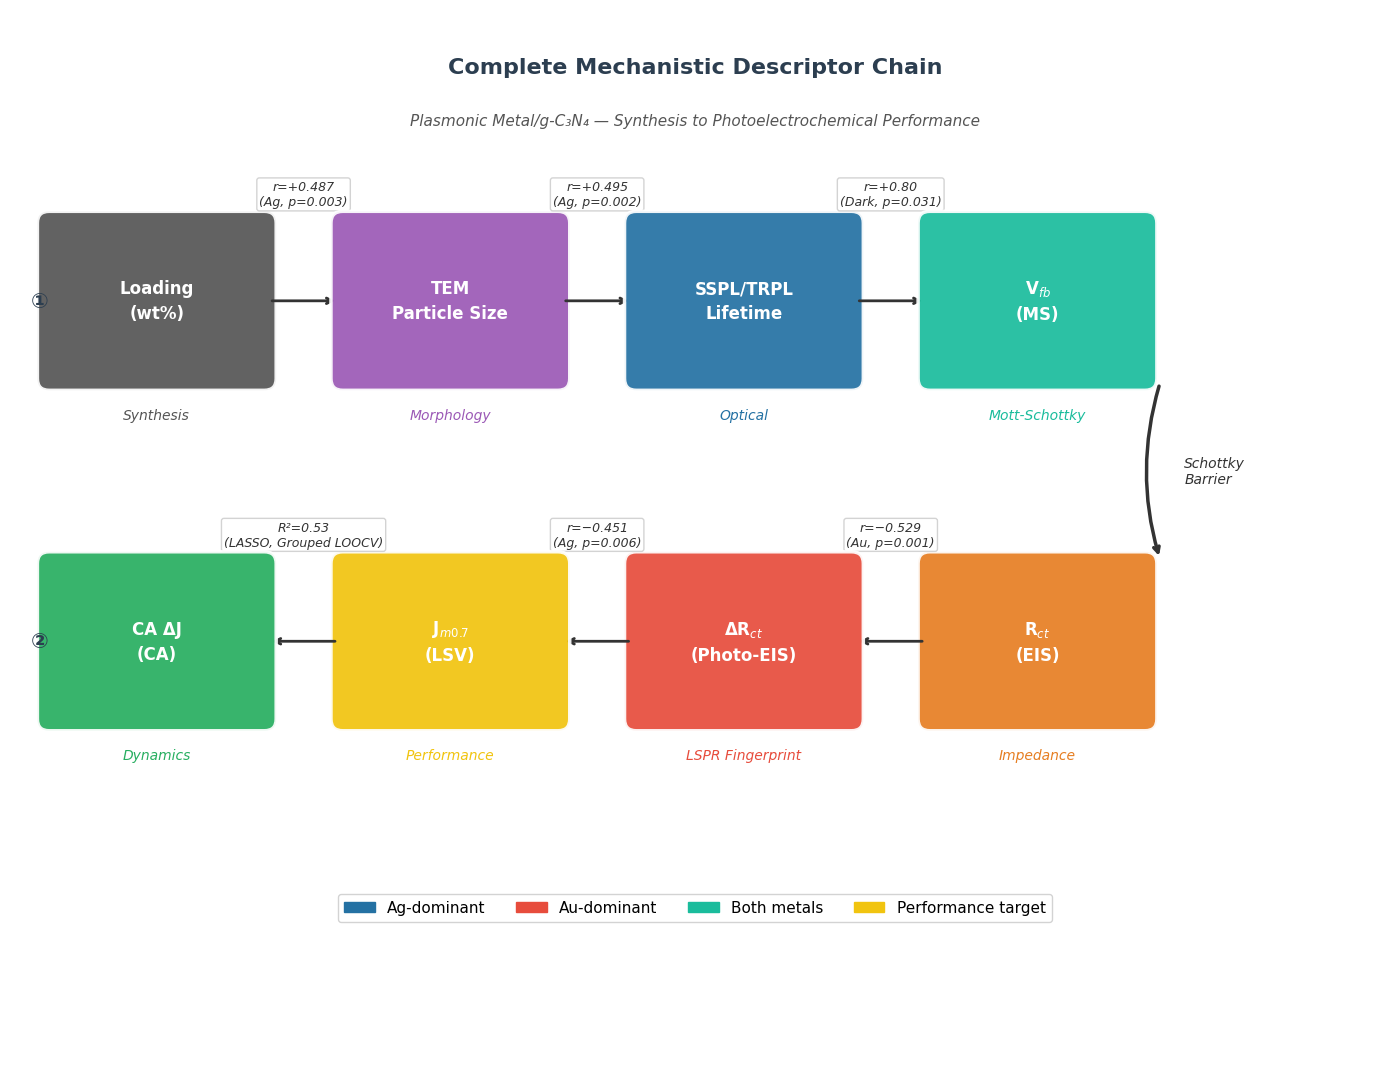

Saved: Results/mechanistic_chain.png


In [12]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 11))
ax.set_xlim(0, 14)
ax.set_ylim(0, 11)
ax.axis('off')
fig.patch.set_facecolor('white')

row1 = [
    ("Loading\n(wt%)",         "Synthesis",         "#555555",  1.5, 8.0),
    ("TEM\nParticle Size",      "Morphology",        "#9B59B6",  4.5, 8.0),
    ("SSPL/TRPL\nLifetime",     "Optical",           "#2471A3",  7.5, 8.0),
    ("V$_{fb}$\n(MS)",          "Mott-Schottky",     "#1ABC9C", 10.5, 8.0),
]

row2 = [
    ("R$_{ct}$\n(EIS)",         "Impedance",         "#E67E22", 10.5, 4.5),
    ("ΔR$_{ct}$\n(Photo-EIS)",  "LSPR Fingerprint",  "#E74C3C",  7.5, 4.5),
    ("J$_{m0.7}$\n(LSV)",       "Performance",       "#F1C40F",  4.5, 4.5),
    ("CA ΔJ\n(CA)",             "Dynamics",          "#27AE60",  1.5, 4.5),
]

arrow_labels_row1 = [
    "r=+0.487\n(Ag, p=0.003)",
    "r=+0.495\n(Ag, p=0.002)",
    "r=+0.80\n(Dark, p=0.031)",
]
arrow_labels_row2 = [
    "r=−0.529\n(Au, p=0.001)",
    "r=−0.451\n(Ag, p=0.006)",
    f"R²={r2_final:.2f}\n(LASSO, Grouped LOOCV)",
]

box_w = 2.2
box_h = 1.6

def draw_box(ax, x, y, name, category, color):
    fancy = mpatches.FancyBboxPatch(
        (x - box_w/2, y - box_h/2), box_w, box_h,
        boxstyle="round,pad=0.12",
        facecolor=color, edgecolor='white',
        linewidth=2.5, alpha=0.92, zorder=3
    )
    ax.add_patch(fancy)
    ax.text(x, y, name, ha='center', va='center',
            fontsize=12, fontweight='bold', color='white',
            zorder=4, linespacing=1.5)
    ax.text(x, y - box_h/2 - 0.3, category,
            ha='center', va='top', fontsize=10,
            color=color, fontstyle='italic')

for i, (name, cat, color, x, y) in enumerate(row1):
    draw_box(ax, x, y, name, cat, color)
    if i < len(row1) - 1:
        x_next = row1[i+1][3]
        ax.annotate('', xy=(x_next - box_w/2 - 0.05, y), xytext=(x + box_w/2 + 0.05, y),
            arrowprops=dict(arrowstyle='->', color='#333333', lw=2.0))
        mid_x = (x + x_next) / 2
        ax.text(mid_x, y + 0.95, arrow_labels_row1[i],
                ha='center', va='bottom', fontsize=9, color='#333333', style='italic',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#CCCCCC', alpha=0.85))

for i, (name, cat, color, x, y) in enumerate(row2):
    draw_box(ax, x, y, name, cat, color)
    if i < len(row2) - 1:
        x_next = row2[i+1][3]
        ax.annotate('', xy=(x_next + box_w/2 + 0.05, y), xytext=(x - box_w/2 - 0.05, y),
            arrowprops=dict(arrowstyle='->', color='#333333', lw=2.0))
        mid_x = (x + x_next) / 2
        ax.text(mid_x, y + 0.95, arrow_labels_row2[i],
                ha='center', va='bottom', fontsize=9, color='#333333', style='italic',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#CCCCCC', alpha=0.85))

x_corner = 11.75
ax.annotate('', xy=(x_corner, row2[0][4] + box_h/2 + 0.05),
    xytext=(x_corner, row1[-1][4] - box_h/2 - 0.05),
    arrowprops=dict(arrowstyle='->', color='#333333', lw=2.5, connectionstyle='arc3,rad=0.15'))
ax.text(x_corner + 0.25, (row1[-1][4] + row2[0][4]) / 2, "Schottky\nBarrier",
        ha='left', va='center', fontsize=10, color='#333333', style='italic')

ax.text(7, 10.4, 'Complete Mechanistic Descriptor Chain',
        ha='center', va='center', fontsize=16, fontweight='bold', color='#2C3E50')
ax.text(7, 9.85, 'Plasmonic Metal/g-C₃N₄ — Synthesis to Photoelectrochemical Performance',
        ha='center', va='center', fontsize=11, color='#555555', style='italic')

ax.text(0.3, 8.0, '①', ha='center', va='center', fontsize=15, color='#2C3E50', fontweight='bold')
ax.text(0.3, 4.5, '②', ha='center', va='center', fontsize=15, color='#2C3E50', fontweight='bold')

ag_patch   = mpatches.Patch(color='#2471A3', label='Ag-dominant')
au_patch   = mpatches.Patch(color='#E74C3C', label='Au-dominant')
both_patch = mpatches.Patch(color='#1ABC9C', label='Both metals')
perf_patch = mpatches.Patch(color='#F1C40F', label='Performance target')
ax.legend(handles=[ag_patch, au_patch, both_patch, perf_patch],
          loc='lower center', fontsize=11, framealpha=0.85,
          bbox_to_anchor=(0.5, 0.14), ncol=4)

plt.tight_layout()
plt.savefig('Results/mechanistic_chain.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: Results/mechanistic_chain.png")

Synthesis, morphology, optical/carrier dynamics, Schottky barrier, interfacial
impedance, and integrated photocurrent are linked in one chain, with the final
photocurrent result (LASSO, alpha=0.05, grouped LOOCV R²=0.53) labeled on the last
arrow.